# Plot the white light curve for both visits

In [1]:
from preamble_jax import *

Available devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7)]
CPU devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7)]


2026-05-28 18:11:18,551 - WARNING - File .dacerc not found. You are requesting data in public mode. To change this behaviour, create a .dacerc file in your home directory and fill it with your API key. More infos on https://dace.unige.ch
/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/chromatic/imports.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import copy, pkg_resources, os, glob, pickle


🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/162 [00:00<?, ?it/s]

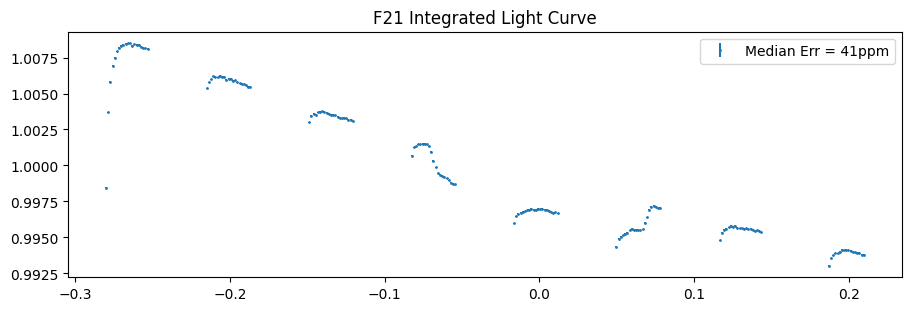

<Figure size 640x480 with 0 Axes>

In [2]:
visit = 'F21'

orbits_to_exclude = np.array([0,2])
lc_index = 1 if visit=='F21' else 0
bin_edges = jnp.array([0.8,1.135,1.645]) * u.micron

predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
binwidth = visits[f'{visit}']['native resolution']
exptime = visits[f'{visit}']['exp (s)']
grism = visits[f'{visit}']['Grism']

rainbow = read_rainbow(f'../../data/rainbows/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy')
binned_for_model = rainbow.bin(wavelength_edges=bin_edges)
fleck_wavelengths = binned_for_model.wavelength.value

integrated_flux = np.trapz(rainbow.flux.value,x=rainbow.wavelength.value,axis=0)

img_date = rainbow.time.value
data_flux = integrated_flux/integrated_flux.mean()
relative_err = np.sqrt(integrated_flux/rainbow.nwave)/integrated_flux
time_from_T0 = img_date - predicted_T0

plt.figure(figsize=(9,3))
plt.errorbar(time_from_T0,data_flux,relative_err,
             label=f'Median Err = {int(np.nanmedian(relative_err)*1e6) }ppm',
            fmt='o',ms=1)
plt.legend()
plt.title(f'{visit} Integrated Light Curve')
plt.show()
plt.clf()

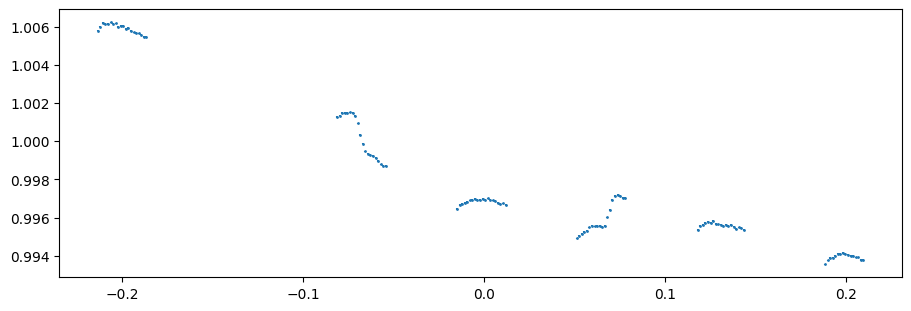

<Figure size 640x480 with 0 Axes>

In [3]:
# Label the orbits
orbit = np.zeros_like(img_date)
for j in range(len(img_date)):
    if j >= 1:
        if (img_date[j] - img_date[j - 1]) > 0.01:
            orbit[j] = (orbit[j - 1] + 1)
        else:
            orbit[j] = orbit[j - 1]

# Trim the first point from each orbit
ref_time = []
for o in np.unique(orbit):
    first_index = np.where(orbit == o)[0][0]
    ref_time.append(img_date[first_index])
    data_flux[first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
    relative_err[first_index] = np.nan
    img_date[first_index] = np.nan
    time_from_T0[first_index] = np.nan

# Set data to nan if it was in the pre-defined list of orbits to exclude
for orbit_to_exclude in orbits_to_exclude:
    data_flux[orbit == orbit_to_exclude] = np.nan
    relative_err[orbit == orbit_to_exclude] = np.nan
    img_date[orbit == orbit_to_exclude] = np.nan
    time_from_T0[orbit == orbit_to_exclude] = np.nan

plt.figure(figsize=(9,3) )
plt.errorbar(time_from_T0,data_flux,yerr=relative_err,fmt='o',ms=1)
plt.show()
plt.clf()

# Populate ramp_phase time arrays
phase_list=[]
for o in [0,1,2,3,4,5,6,7]:
    rphase = (img_date[orbit==o] - ref_time[o]) / 0.066
    phase_list.append(rphase)
ramp_phase = np.concatenate(phase_list)
breathing_phase = ( (img_date-ref_time[0]+0.02) / 0.066 ) % 1

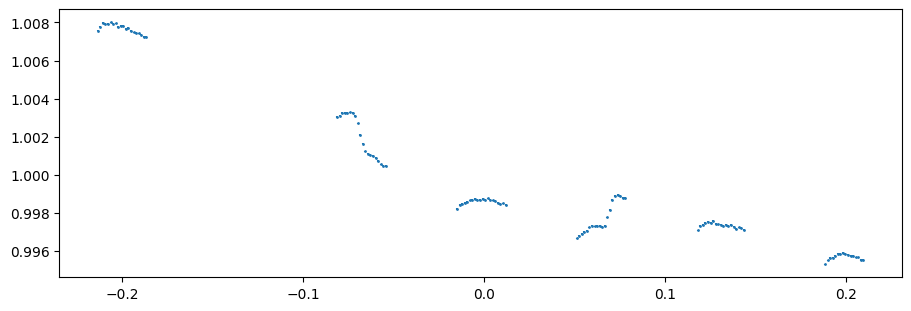

<Figure size 640x480 with 0 Axes>

In [4]:
# Convert all arrays to JAX arrays
_data_flux = jnp.array( data_flux[~np.isnan(time_from_T0)] )
data_flux = _data_flux[~jnp.isnan(_data_flux)]
_relative_err = jnp.array(relative_err[~np.isnan(time_from_T0)] )
relative_err = _relative_err[~jnp.isnan(_data_flux)]
_img_date = jnp.array(img_date[~np.isnan(time_from_T0)] )
img_date = _img_date[~jnp.isnan(_data_flux)]
_time_from_T0 = jnp.array(time_from_T0[~np.isnan(time_from_T0)] )
time_from_T0 = _time_from_T0[~jnp.isnan(_data_flux)]
_ramp_phase = jnp.array(ramp_phase[~np.isnan(ramp_phase)] )
ramp_phase = _ramp_phase[~jnp.isnan(_data_flux)]
_breathing_phase = jnp.array(breathing_phase[~np.isnan(breathing_phase)] )
breathing_phase = _breathing_phase[~jnp.isnan(_data_flux)]

normalized_data_flux = data_flux/jnp.mean(data_flux)
normalized_relative_err = relative_err*normalized_data_flux

plt.figure(figsize=(9,3) )
plt.errorbar(time_from_T0,normalized_data_flux,yerr=normalized_relative_err,fmt='o',ms=1)
plt.show()
plt.clf()

In [5]:
default_params={

    # Ramp Model Parameters
    'r_1': 18.1,
    'r_2': -6.7,
    'r_3': 0.0135,
    #Breathing params
    'b_1':0,
    'b_2':0,
    'b_3':0,
    'b_4':0,
    
    # Planet parameters
    'Mp':8.0,
    'i_planet':89.5,
    'P_orb':8.463,
    't_0':0.00048,
    'rp_rstar': 0.0465,
    'a_rstar': 19.15,
    'ecc': 0.0,
    'u_1':0.35,
    'u_2':0.15,
    
    # Stellar parameters
    'log_g':4.5,
    'i_star':89.5,
    'P_rot':4.86,
    'Rs':0.8,
    'Ms':0.6,
    'metallicity':0.0,

    # Spot Parameters
    # 'log_fixedspot_radii':-2.0,
    # 'T_unocculted': 3100,
    # 'T_occulted': 3500,
    'T_phot': 4100,
    'T_spot': 3500,
    'limb_spot_lon':-1.305,
    'limb_spot_lat':0.9,
    'limb_spot_rad':0.22,
    'chord_spot_lon_1':0.05,
    'chord_spot_lat_1':1.54,
    'chord_spot_rad_1':0.15,
    'chord_spot_lon_2':0.86,
    'chord_spot_lat_2':1.66,
    'chord_spot_rad_2':0.055,

    # Model meta-parameters
    'beta':0.25,

}

In [6]:
def numpyro_model():

    """
    Define the probabilistic model in NUMPYRO
    """
    params = {}

    # Instrument Parameters
    params['r_1'] = numpyro.sample('r_1', dist.Uniform(6.0, 17.0))
    params['r_2'] = numpyro.sample('r_2', dist.Uniform(-7.0, -6.25))
    params['r_3'] = numpyro.sample('r_3', dist.Uniform(0.0,0.025))

    # Instrument Parameters
    params['b_1'] = numpyro.sample('b_1', dist.Uniform(-0.035,0.02))
    params['b_2'] = numpyro.sample('b_2', dist.Uniform(-0.12,0.05))
    params['b_3'] = numpyro.sample('b_3', dist.Uniform(-0.05,0.16))
    params['b_4'] = numpyro.sample('b_4', dist.Uniform(-0.08,0.025))

    # Baseline Parameters
    params['limb_spot_lon'] = numpyro.sample('limb_spot_lon', dist.Uniform(-1.31, -1.29))
    params['limb_spot_lat'] = 0.9 #numpyro.sample('limb_spot_lat', dist.Uniform(0.65, 1.15))
    params['limb_spot_rad'] = numpyro.sample('limb_spot_rad', dist.Uniform(0.26, 0.37))
    
    params['chord_spot_lon_1'] = numpyro.sample('chord_spot_lon_1', dist.Uniform(0.035, 0.085))
    params['chord_spot_lat_1'] = numpyro.sample('chord_spot_lat_1', dist.Uniform(1.5, 1.7))
    params['chord_spot_rad_1'] = numpyro.sample('chord_spot_rad_1', dist.Uniform(0.0, 0.2))

    params['chord_spot_lon_2'] = numpyro.sample('chord_spot_lon_2', dist.Uniform(0.84,0.88))
    params['chord_spot_lat_2'] = numpyro.sample('chord_spot_lat_2', dist.Uniform(1.74, 1.83))
    params['chord_spot_rad_2'] = numpyro.sample('chord_spot_rad_2', dist.Uniform(0.03, 0.09))

    # Planet Parameters
    params['rp_rstar'] = numpyro.sample('rp_rstar', dist.Uniform(0.0475, 0.0495))
    params['t_0'] = numpyro.sample('t_0', dist.Uniform(0.0003, 0.0008)) 
    params['a_rstar'] = numpyro.sample('a', dist.Uniform(18.0, 20))
    
    params['u_1'] = numpyro.sample('u_1', dist.Uniform(0.1,0.45))
    params['u_2'] = numpyro.sample('u_2', dist.Uniform(0.13,0.5))
    
    # Stellar Parameters
    params['T_phot'] = 3891
    params['T_spot'] = 3020 #numpyro.sample('T_spot', dist.Uniform(3400,3600))
    beta = numpyro.sample('beta', dist.Uniform(0.0, 0.4))

    @jit
    def broadband_transit(params,**kwargs):

        # Calculate systematics model
        ramp = ramp_model_jax(phase=ramp_phase,
                        r1=jnp.asarray(params['r_1'], dtype=jnp.float64),
                        r2=jnp.asarray(params['r_2'], dtype=jnp.float64),
                        r3=jnp.asarray(params['r_3'], dtype=jnp.float64) )
        breathing = breathing_model_jax(phase=breathing_phase,
                                  b1=jnp.asarray(params['b_1'], dtype=jnp.float64),
                                  b2=jnp.asarray(params['b_2'], dtype=jnp.float64),
                                  b3=jnp.asarray(params['b_3'], dtype=jnp.float64),
                                  b4=jnp.asarray(params['b_4'], dtype=jnp.float64))
        _systematics = (breathing * ramp)
        systematics = _systematics/jnp.mean(_systematics)
        
        # Update Planet Parameters
        planet_parameters = dict(
            inclination = jnp.radians(default_params['i_planet']),
            a = jnp.asarray(params['a_rstar'], dtype=jnp.float64),
            rp = jnp.asarray(params['rp_rstar'], dtype=jnp.float64),
            period = default_params['P_orb'],
            t0 = jnp.asarray(params['t_0'], dtype=jnp.float64),
            ecc = default_params['ecc'],
            u1 = jnp.asarray(params['u_1'], dtype=jnp.float64),
            u2 = jnp.asarray(params['u_2'], dtype=jnp.float64)
        )
        
        # Get spectra for the model temps
        Phot = get_binned_BTSettl_spectrum_jax(T=params['T_phot'],data_wave = fleck_wavelengths)
        Cool = get_binned_BTSettl_spectrum_jax(T=params['T_spot'],data_wave = fleck_wavelengths)
        
        # Update stellar parameters
        active_star = ActiveStar(
            times = time_from_T0,
            inclination=jnp.radians(default_params['i_star']),
            T_eff=jnp.asarray(params['T_phot'], dtype=jnp.float64),
            wavelength=Phot[0]*1e-6, # convert from micron to m
            phot=Phot[1],
            P_rot=default_params['P_rot']
        )
        
        active_star.spectrum = jnp.concatenate([
            jnp.vstack([Cool[1],
                        Cool[1],
                        Cool[1]
                       ]),
        ])
        active_star.temperature = jnp.concatenate([
            jnp.array([params['T_spot'],
                       params['T_spot'],
                       params['T_spot']
                      ]),
        ])
        active_star.lon = jnp.concatenate([
            jnp.array([params['limb_spot_lon'],
                       params['chord_spot_lon_1'],
                       params['chord_spot_lon_2']
                      ]),
        ])
        active_star.lat = jnp.concatenate([
            jnp.array([params['limb_spot_lat'],
                       params['chord_spot_lat_1'], 
                       params['chord_spot_lat_2']
                      ]),
        ])
        active_star.rad = jnp.concatenate([
            jnp.array([params['limb_spot_rad'], 
                       params['chord_spot_rad_1'], 
                       params['chord_spot_rad_2']
                      ]),
        ])        
        
        lc, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)        
        lc_model = lc.T[lc_index] * systematics
        mean_per_wavelength = jnp.mean(lc_model)
        normalized_model = lc_model / mean_per_wavelength
    
        return normalized_model

    numpyro.sample(
        'Obs', dist.Normal(
            loc=broadband_transit(params), 
            scale=(10**beta)*normalized_relative_err,
        ), obs=normalized_data_flux
    )

In [7]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np

# Default parameters
default_params = {
    # Ramp Model Parameters
    'r_1': 14.28,
    'r_2': -6.82,
    'r_3': 0.0045,
    # Breathing params
    'b_1': -0.003,
    'b_2': -0.003,
    'b_3': -0.001,
    'b_4': 0.003,
    
    # Planet parameters
    'Mp': 8.0,
    'i_planet': 89.5,
    'P_orb': 8.463,
    't_0': 0.0004,
    'rp_rstar': 0.04656,
    'a_rstar': 19.15,
    'ecc': 0.0,
    'u_1': 0.23,
    'u_2': 0.20,
    
    # Stellar parameters
    'log_g': 4.5,
    'i_star': 89.5,
    'P_rot': 4.86,
    'Rs': 0.8,
    'Ms': 0.6,
    'metallicity': 0.0,

    # Spot Parameters
    'T_phot': 3891,
    'T_spot': 3020,
    'limb_spot_lon': -1.249,
    'limb_spot_lat': 0.9,
    'limb_spot_rad': 0.276,
    'chord_spot_lon_1': 0.065,
    'chord_spot_lat_1': 1.469,
    'chord_spot_rad_1': 0.274,
    'chord_spot_lon_2': 0.065,
    'chord_spot_lat_2': 1.641,
    'chord_spot_rad_2': 0.07,
    # Additional spot
    'chord_spot_lon_3': -0.02,
    'chord_spot_lat_3': 1.75,
    'chord_spot_rad_3': 0.0,

    # Model meta-parameters
    'beta': 0.25,
}

def create_parameter_widgets(default_params):
    """Create widgets for all configurable parameters with ranges from numpyro model"""
    widgets_dict = {
        # Ramp parameters 
        'r_1': widgets.FloatSlider(value=default_params['r_1'], min=10.0, max=20.0, step=0.01, 
                                   description='r_1', readout_format='.2f'),
        'r_2': widgets.FloatSlider(value=default_params['r_2'], min=-8.0, max=-6.0, step=0.01, 
                                   description='r_2', readout_format='.3f'),
        'r_3': widgets.FloatSlider(value=default_params['r_3'], min=-0.1, max=0.1, step=0.002, 
                                   description='r_3', readout_format='.4f'),
        
        # Breathing parameters 
        'b_1': widgets.FloatSlider(value=default_params['b_1'], min=-0.1, max=0.1, step=0.001, 
                                   description='b_1', readout_format='.3f'),
        'b_2': widgets.FloatSlider(value=default_params['b_2'], min=-0.1, max=0.1, step=0.001, 
                                   description='b_2', readout_format='.3f'),
        'b_3': widgets.FloatSlider(value=default_params['b_3'], min=-0.1, max=0.1, step=0.001, 
                                   description='b_3', readout_format='.3f'),
        'b_4': widgets.FloatSlider(value=default_params['b_4'], min=-0.1, max=0.1, step=0.001, 
                                   description='b_4', readout_format='.3f'),
        
        # Planet parameters 
        'rp_rstar': widgets.FloatSlider(value=default_params['rp_rstar'], min=0.045, max=0.05, 
                                        step=0.0001, description='Rp/R*', readout_format='.4f'),
        'a_rstar': widgets.FloatText(value=default_params['a_rstar'], description='a/R*'),
        'P_orb': widgets.FloatText(value=default_params['P_orb'], description='Period (d)'),
        't_0': widgets.FloatSlider(value=default_params['t_0'], min=0.0003, max=0.0008, 
                                   step=0.00001, description='T0', readout_format='.5f'),
        'ecc': widgets.FloatText(value=default_params['ecc'], description='Ecc'),
        
        # Limb darkening
        'u_1': widgets.FloatSlider(value=default_params['u_1'], min=0.1, max=0.5, step=0.01, 
                                   description='u1', readout_format='.2f'),
        'u_2': widgets.FloatSlider(value=default_params['u_2'], min=0.1, max=0.5, step=0.01, 
                                   description='u2', readout_format='.2f'),
        
        # Temperature parameters 
        'T_phot': widgets.FloatText(value=default_params['T_phot'], description='T_phot'),
        'T_spot': widgets.FloatText(value=default_params['T_spot'], description='T_spot'),
        
        # Spot parameters 
        'limb_spot_lon': widgets.FloatSlider(value=default_params['limb_spot_lon'], 
                                            min=-1.32, max=-1.2, step=0.01, 
                                            description='Limb lon', readout_format='.2f'),
        'limb_spot_lat': widgets.FloatText(value=default_params['limb_spot_lat'], description='Limb lat'),
        'limb_spot_rad': widgets.FloatSlider(value=default_params['limb_spot_rad'], 
                                            min=0.1, max=0.4, step=0.005, 
                                            description='Limb rad', readout_format='.2f'),
        
        # Chord spot 1 
        'chord_spot_lon_1': widgets.FloatSlider(value=default_params['chord_spot_lon_1'], 
                                               min=0.03, max=0.09, step=0.001, 
                                               description='Chord1 lon', readout_format='.3f'),
        'chord_spot_lat_1': widgets.FloatSlider(value=default_params['chord_spot_lat_1'], 
                                               min=1.5, max=1.8, step=0.01, 
                                               description='Chord1 lat', readout_format='.2f'),
        'chord_spot_rad_1': widgets.FloatSlider(value=default_params['chord_spot_rad_1'], 
                                               min=0.0, max=0.4, step=0.01, 
                                               description='Chord1 rad', readout_format='.2f'),
        
        # Chord spot 2 
        'chord_spot_lon_2': widgets.FloatSlider(value=default_params['chord_spot_lon_2'], 
                                               min=0.84, max=0.88, step=0.001, 
                                               description='Chord2 lon', readout_format='.3f'),
        'chord_spot_lat_2': widgets.FloatSlider(value=default_params['chord_spot_lat_2'], 
                                               min=1.74, max=1.83, step=0.01, 
                                               description='Chord2 lat', readout_format='.2f'),
        'chord_spot_rad_2': widgets.FloatSlider(value=default_params['chord_spot_rad_2'], 
                                               min=0.0, max=0.15, step=0.001, 
                                               description='Chord2 rad', readout_format='.3f'),
        
        # Additional chord spot 3 (starting with rad=0)
        'chord_spot_lon_3': widgets.FloatSlider(value=default_params['chord_spot_lon_3'], 
                                               min=-0.06, max=0.05, step=0.01, 
                                               description='Chord3 lon', readout_format='.3f'),
        'chord_spot_lat_3': widgets.FloatSlider(value=default_params['chord_spot_lat_3'], 
                                               min=1.7, max=1.8, step=0.01, 
                                               description='Chord3 lat', readout_format='.2f'),
        'chord_spot_rad_3': widgets.FloatSlider(value=default_params['chord_spot_rad_3'], 
                                               min=0.0, max=0.1, step=0.001, 
                                               description='Chord3 rad', readout_format='.3f'),
        
        # Noise parameter (from numpyro: beta: U(0.0, 0.165))
        'beta': widgets.FloatSlider(value=default_params['beta'], min=0.0, max=0.25, step=0.01, 
                                    description='beta', readout_format='.3f'),
    }
    return widgets_dict

def get_params_from_widgets(widgets_dict):
    """Extract parameter values from widgets"""
    return {key: widget.value for key, widget in widgets_dict.items()}

def plot_results_interactive(default_params, ramp_phase, breathing_phase, 
                            fleck_wavelengths, time_from_T0, lc_index,
                            normalized_data_flux, normalized_relative_err,
                            visit, model_designation):
    """
    Interactive version of plot_results with sliders for all parameters.
    """
    # Create widgets
    param_widgets = create_parameter_widgets(default_params)
    
    # Create output area for the plot
    output = widgets.Output()
    
    # Add controls for save functionality
    save_button = widgets.Button(description="Save Current Plot", 
                                button_style='success',
                                layout=widgets.Layout(width='200px'))
    save_filename = widgets.Text(value='interactive_plot', 
                                description='Filename:',
                                layout=widgets.Layout(width='300px'))
    
    # Add reset button
    reset_button = widgets.Button(description="Reset to Defaults", 
                                 button_style='warning',
                                 layout=widgets.Layout(width='200px'))
    
    # Status indicator
    status_label = widgets.Label(value="Ready", layout=widgets.Layout(width='100px'))
    
    def update_plot(change=None):
        """Update the plot when any parameter changes"""
        with output:
            clear_output(wait=True)
            status_label.value = "Updating..."
            current_params = get_params_from_widgets(param_widgets)
            plot_results(current_params, 
                        ramp_phase=ramp_phase,
                        breathing_phase=breathing_phase,
                        fleck_wavelengths=fleck_wavelengths,
                        time_from_T0=time_from_T0,
                        lc_index=lc_index,
                        normalized_data_flux=normalized_data_flux,
                        normalized_relative_err=normalized_relative_err,
                        visit=visit,
                        model_designation=model_designation,
                        figlabel='interactive')
            status_label.value = "Ready"
    
    def save_current_plot(button):
        """Save the current plot with custom filename"""
        status_label.value = "Saving..."
        current_params = get_params_from_widgets(param_widgets)
        plot_results(current_params,
                    ramp_phase=ramp_phase,
                    breathing_phase=breathing_phase,
                    fleck_wavelengths=fleck_wavelengths,
                    time_from_T0=time_from_T0,
                    lc_index=lc_index,
                    normalized_data_flux=normalized_data_flux,
                    normalized_relative_err=normalized_relative_err,
                    visit=visit,
                    model_designation=model_designation,
                    figlabel=save_filename.value)
        status_label.value = f"Saved as {save_filename.value}"
    
    def reset_to_defaults(button):
        """Reset all widgets to their default values"""
        for key, widget in param_widgets.items():
            if key in default_params:
                widget.value = default_params[key]
        status_label.value = "Reset to defaults"
    
    # Attach observers to all widgets (use debounced updates for better performance)
    for widget in param_widgets.values():
        widget.observe(update_plot, names='value')
    
    save_button.on_click(save_current_plot)
    reset_button.on_click(reset_to_defaults)
    
    # Organize widgets in tabs for better organization
    ramp_tab = widgets.VBox([
        widgets.HTML("<b>Ramp Parameters</b>"),
        param_widgets['r_1'], param_widgets['r_2'], param_widgets['r_3']
    ])
    
    breathing_tab = widgets.VBox([
        widgets.HTML("<b>Breathing Parameters</b>"),
        param_widgets['b_1'], param_widgets['b_2'], 
        param_widgets['b_3'], param_widgets['b_4']
    ])
    
    planet_tab = widgets.VBox([
        widgets.HTML("<b>Planet Parameters</b>"),
        param_widgets['rp_rstar'], param_widgets['a_rstar'],
        param_widgets['P_orb'], param_widgets['t_0'], 
        param_widgets['ecc'], 
        widgets.HTML("<b>Limb Darkening</b>"),
        param_widgets['u_1'], param_widgets['u_2']
    ])
    
    stellar_tab = widgets.VBox([
        widgets.HTML("<b>Stellar Parameters</b>"),
        param_widgets['T_phot'], param_widgets['T_spot']
    ])
    
    spots_tab = widgets.VBox([
        widgets.HTML("<b>Limb Spot</b>"),
        param_widgets['limb_spot_lon'], param_widgets['limb_spot_lat'],
        param_widgets['limb_spot_rad'],
        widgets.HTML("<b>Chord Spot 1</b>"),
        param_widgets['chord_spot_lon_1'], param_widgets['chord_spot_lat_1'],
        param_widgets['chord_spot_rad_1'],
        widgets.HTML("<b>Chord Spot 2</b>"),
        param_widgets['chord_spot_lon_2'], param_widgets['chord_spot_lat_2'],
        param_widgets['chord_spot_rad_2'],
        widgets.HTML("<b>Additional Spot (Chord Spot 3)</b>"),
        param_widgets['chord_spot_lon_3'], param_widgets['chord_spot_lat_3'],
        param_widgets['chord_spot_rad_3']
    ])
    
    noise_tab = widgets.VBox([
        widgets.HTML("<b>Noise & Meta Parameters</b>"),
        param_widgets['beta']
    ])
    
    tabs = widgets.Tab([ramp_tab, breathing_tab, planet_tab, stellar_tab, spots_tab, noise_tab])
    tabs.set_title(0, 'Ramp')
    tabs.set_title(1, 'Breathing')
    tabs.set_title(2, 'Planet')
    tabs.set_title(3, 'Stellar')
    tabs.set_title(4, 'Spots')
    tabs.set_title(5, 'Noise')
    
    # Create control panel
    control_panel = widgets.HBox([
        save_button, 
        save_filename, 
        reset_button, 
        status_label
    ], layout=widgets.Layout(justify_content='space-between', padding='10px'))
    
    # Display everything
    display(widgets.VBox([
        widgets.HTML("<h3>Interactive Parameter Explorer</h3>"),
        control_panel,
        tabs,
        output
    ]))
    
    # Initial plot
    update_plot()

# Modified plot_results function - now includes the additional spot
def plot_results(parameter_dict,
                 ramp_phase=None,
                 breathing_phase=None,
                 fleck_wavelengths=None,
                 time_from_T0=None,
                 lc_index=None,
                 normalized_data_flux=None,
                 normalized_relative_err=None,
                 visit='unknown',
                 model_designation='model',
                 figlabel='missinglabel'):
    """
    Modified version that accepts all necessary data as parameters
    rather than relying on global variables.
    Now includes an additional spot (chord_spot_3).
    """
    params = parameter_dict
    
    # Calculate systematics model
    ramp = ramp_model_jax(phase=ramp_phase,
                    r1=jnp.asarray(params.get('r_1', default_params['r_1']), dtype=jnp.float64),
                    r2=jnp.asarray(params.get('r_2', default_params['r_2']), dtype=jnp.float64),
                    r3=jnp.asarray(params.get('r_3', default_params['r_3']), dtype=jnp.float64))
    breathing = breathing_model_jax(phase=breathing_phase,
                              b1=jnp.asarray(params.get('b_1', default_params['b_1']), dtype=jnp.float64),
                              b2=jnp.asarray(params.get('b_2', default_params['b_2']), dtype=jnp.float64),
                              b3=jnp.asarray(params.get('b_3', default_params['b_3']), dtype=jnp.float64),
                              b4=jnp.asarray(params.get('b_4', default_params['b_4']), dtype=jnp.float64))
    _systematics = (breathing * ramp)
    systematics = _systematics/jnp.mean(_systematics)
    
    # Update Planet Parameters
    planet_parameters = dict(
        inclination=jnp.radians(default_params['i_planet']),
        a=jnp.asarray(params.get('a_rstar', default_params['a_rstar']), dtype=jnp.float64),
        rp=jnp.asarray(params.get('rp_rstar', default_params['rp_rstar']), dtype=jnp.float64),
        period=jnp.asarray(params.get('P_orb', default_params['P_orb']), dtype=jnp.float64),
        t0=jnp.asarray(params.get('t_0', default_params['t_0']), dtype=jnp.float64),
        ecc=jnp.asarray(params.get('ecc', default_params['ecc']), dtype=jnp.float64),
        u1=jnp.asarray(params.get('u_1', default_params['u_1']), dtype=jnp.float64),
        u2=jnp.asarray(params.get('u_2', default_params['u_2']), dtype=jnp.float64),
    )
    rotation_planet_parameters = dict(
        inclination=jnp.radians(default_params['i_planet']),
        a=jnp.asarray(params.get('a_rstar', default_params['a_rstar']), dtype=jnp.float64),
        rp=jnp.asarray(0.0, dtype=jnp.float64),  # Set rp=0 for rotation only
        period=jnp.asarray(params.get('P_orb', default_params['P_orb']), dtype=jnp.float64),
        t0=jnp.asarray(params.get('t_0', default_params['t_0']), dtype=jnp.float64),
        ecc=jnp.asarray(params.get('ecc', default_params['ecc']), dtype=jnp.float64),
        u1=jnp.asarray(params.get('u_1', default_params['u_1']), dtype=jnp.float64),
        u2=jnp.asarray(params.get('u_2', default_params['u_2']), dtype=jnp.float64),
    )
    
    # Get spectra for the model temps
    Phot = get_binned_BTSettl_spectrum_jax(T=jnp.asarray(params.get('T_phot', default_params['T_phot']), dtype=jnp.float64),
                                           data_wave=fleck_wavelengths)
    Cool = get_binned_BTSettl_spectrum_jax(T=jnp.asarray(params.get('T_spot', default_params['T_spot']), dtype=jnp.float64),
                                           data_wave=fleck_wavelengths)
    
    # Update stellar parameters
    active_star = ActiveStar(
        times=time_from_T0,
        inclination=jnp.radians(default_params['i_star']),
        T_eff=jnp.asarray(params.get('T_phot', default_params['T_phot']), dtype=jnp.float64),
        wavelength=Phot[0]*1e-6,  # convert from micron to m
        phot=Phot[1],
        P_rot=default_params['P_rot']
    )
    
    # Now including the additional spot (4 spots total: 1 limb + 3 chord)
    active_star.spectrum = jnp.concatenate([
        jnp.vstack([Cool[1], Cool[1], Cool[1], Cool[1]]),  # Added one more for the new spot
    ])
    active_star.temperature = jnp.concatenate([
        jnp.array([params.get('T_spot', default_params['T_spot']),
                   params.get('T_spot', default_params['T_spot']),
                   params.get('T_spot', default_params['T_spot']),
                   params.get('T_spot', default_params['T_spot'])]),  # Added one more for the new spot
    ])
    active_star.lon = jnp.concatenate([
        jnp.array([params.get('limb_spot_lon', default_params['limb_spot_lon']),
                   params.get('chord_spot_lon_1', default_params['chord_spot_lon_1']),
                   params.get('chord_spot_lon_2', default_params['chord_spot_lon_2']),
                   params.get('chord_spot_lon_3', default_params['chord_spot_lon_3'])]),  # Added new spot
    ])
    active_star.lat = jnp.concatenate([
        jnp.array([params.get('limb_spot_lat', default_params['limb_spot_lat']),
                   params.get('chord_spot_lat_1', default_params['chord_spot_lat_1']),
                   params.get('chord_spot_lat_2', default_params['chord_spot_lat_2']),
                   params.get('chord_spot_lat_3', default_params['chord_spot_lat_3'])]),  # Added new spot
    ])
    active_star.rad = jnp.concatenate([
        jnp.array([params.get('limb_spot_rad', default_params['limb_spot_rad']),
                   params.get('chord_spot_rad_1', default_params['chord_spot_rad_1']),
                   params.get('chord_spot_rad_2', default_params['chord_spot_rad_2']),
                   params.get('chord_spot_rad_3', default_params['chord_spot_rad_3'])]),  # Added new spot
    ])
    
    lc, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)
    lc_model = lc.T[lc_index] * systematics
    mean_per_wavelength = jnp.mean(lc_model)
    normalized_model = lc_model / mean_per_wavelength
    residuals = normalized_data_flux - normalized_model
    adjusted_flux_err = (10**params.get('beta', default_params['beta'])) * normalized_relative_err
    
    # Calculate rotation-only model (rp=0, no transit)
    rotation_lc, _, _, _, _ = active_star.transit_model(**rotation_planet_parameters)
    
    # Extract rotation curve at the relevant wavelength index
    rotation_curve = rotation_lc.T[lc_index]
    rotation_curve_normalized = rotation_curve / jnp.mean(rotation_curve)
    
    # Calculate the transit model with systematics
    lc_model_with_systematics = lc.T[lc_index] * systematics
    
    # Divide both model and data by rotation curve to get flat baseline
    lc_model_corrected = lc_model_with_systematics / rotation_curve_normalized
    data_corrected = normalized_data_flux / rotation_curve_normalized
    
    # Normalize the corrected model
    mean_per_wavelength = jnp.mean(lc_model_corrected)
    normalized_model = lc_model_corrected / mean_per_wavelength
    
    # Calculate residuals with corrected data
    residuals = data_corrected - normalized_model
    adjusted_flux_err = (10**params.get('beta', default_params['beta'])) * normalized_relative_err
    # Also correct the errors by rotation curve
    adjusted_flux_err_corrected = adjusted_flux_err / rotation_curve_normalized
    
    # Create a 3-panel figure
    plt.figure(figsize=(12, 6))
    gs = plt.GridSpec(2, 2, width_ratios=[1, 2])
    
    # Star visualization panel (showing the star with spots)
    ax_star = plt.subplot(gs[:, 0])
    active_star.plot_star(
        t0=params.get('t_0', default_params['t_0']),
        rp=params.get('rp_rstar', default_params['rp_rstar']),
        a=params.get('a_rstar', default_params['a_rstar']),
        inclination=np.radians(89.5),
        ecc=params.get('ecc', default_params['ecc']),
        ax=ax_star)
    
    # Light curve panel (now with rotation-corrected data)
    ax_lc = plt.subplot(gs[0, 1])
    ax_lc.errorbar(time_from_T0, data_corrected,
                   yerr=adjusted_flux_err_corrected,
                   fmt='o', ms=1, color='k')
    ax_lc.scatter(time_from_T0, normalized_model, s=1, color='r')
    ax_lc.set_ylabel('Relative Flux (Rotation Corrected)')
    ax_lc.set_title(f'{visit} Broadband Light Curve with Model')
    
    # Residuals panel
    ax_res = plt.subplot(gs[1, 1], sharex=ax_lc)
    ax_res.errorbar(time_from_T0, residuals*1e6,
                    yerr=adjusted_flux_err_corrected*1e6,
                    fmt='o', ms=1, color='k')
    ax_res.axhline(y=0, color='r', linestyle='-', alpha=0.5)
    ax_res.set_ylabel('Residual Flux (ppm)')
    ax_res.set_xlabel('Time from T0')
    ax_res.set_title('Data-Model (Rotation Corrected)')
    
    plt.tight_layout()
    plt.savefig(f'../../figs/{model_designation}_{figlabel}.png', dpi=400)
    plt.show()
    plt.clf()
    
    return normalized_model, active_star


plot_results_interactive(
    default_params=default_params,
    ramp_phase=ramp_phase,
    breathing_phase=breathing_phase,
    fleck_wavelengths=fleck_wavelengths,
    time_from_T0=time_from_T0,
    lc_index=lc_index,
    normalized_data_flux=normalized_data_flux,
    normalized_relative_err=normalized_relative_err,
    visit=visit,
    model_designation=None
)


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [8]:
# model_designation = 'F21_70000samples_12chains_3spots_whitelight_2026_01_07' # Current winner
model_designation = 'F21_60000samples_12chains_3spots_whitelight_2025_12_28' # Also good

result = arviz.from_netcdf(f'../../data/samples/{model_designation}')
'Print the summary'
arviz.summary(result)

'Make a corner plot'
corner.corner(
    result,
)
plt.savefig(f'../../figs/{model_designation}_corner.png',dpi=200)

'Examine the Leave-One-Out (LOO) summary'
loo = arviz.loo(result, pointwise=True)
loo

KeyboardInterrupt: 

In [ ]:
# result = arviz.from_netcdf(f'../../data/samples/{model_designation}')

latex_summary = az.summary(result)
latex_summary.to_latex(f"../../results/{model_designation}-results-table.tex", float_format="%.6f")

results = []
for var_name in result.posterior.data_vars:
    samples = result.posterior[var_name].values.flatten()
    
    q16 = np.quantile(samples, 0.16)
    median = np.quantile(samples, 0.50)
    q84 = np.quantile(samples, 0.84)
    
    results.append({
        'parameter': var_name,
        'q16': q16,
        'median': median,
        'q84': q84,
        'lower_err': (median-q16),
        'upper_err':(q84-median)
    })

# Convert to DataFrame
quantile_df = pd.DataFrame(results)
quantile_df = quantile_df.set_index('parameter')

# Save to LaTeX
quantile_df.to_latex(f"../../results/{model_designation}-quantile_results.tex", float_format="%.6f")

## Print and plot the MEDIAN parameter results

In [ ]:
# result = az.from_netcdf(f"../../data/samples/{model_designation}")
final_median_params = arviz.summary(result,stat_focus='median')['median']

final_lc_model, final_star = plot_results(final_median_params,figlabel='Median Parameters')

## Print and plot the Maximum Likelihood Estimate results

In [ ]:
def calculate_model(parameter_dict,relative_flux):
    
    params = parameter_dict

    # Calculate systematics model
    ramp = ramp_model_jax(phase=ramp_phase,
                    r1=jnp.asarray(params.get('r_1',default_params['r_1']), dtype=jnp.float64),
                    r2=jnp.asarray(params.get('r_2',default_params['r_2']), dtype=jnp.float64),
                    r3=jnp.asarray(params.get('r_3',default_params['r_3']), dtype=jnp.float64) )
    breathing = breathing_model_jax(phase=breathing_phase,
                              b1=jnp.asarray(params.get('b_1',default_params['b_1']), dtype=jnp.float64),
                              b2=jnp.asarray(params.get('b_2',default_params['b_2']), dtype=jnp.float64),
                              b3=jnp.asarray(params.get('b_3',default_params['b_3']), dtype=jnp.float64),
                              b4=jnp.asarray(params.get('b_4',default_params['b_4']), dtype=jnp.float64))

    _systematics = (breathing * ramp)
    systematics = _systematics/jnp.mean(_systematics)
    
    # Update Planet Parameters
    planet_parameters = dict(
        inclination = jnp.radians(default_params['i_planet']),
        a = jnp.asarray(params.get('a_rstar',default_params['a_rstar']), dtype=jnp.float64),
        rp = jnp.asarray(params.get('rp_rstar',default_params['rp_rstar']), dtype=jnp.float64),
        period = jnp.asarray(params.get('P_orb',default_params['P_orb']), dtype=jnp.float64),
        t0 = jnp.asarray(params.get('t_0',default_params['t_0']), dtype=jnp.float64),
        ecc = jnp.asarray(params.get('ecc',default_params['ecc']), dtype=jnp.float64),
        u1 = jnp.asarray(params.get('u_1',default_params['u_1']), dtype=jnp.float64),
        u2 = jnp.asarray(params.get('u_2',default_params['u_2']), dtype=jnp.float64),
    )
    no_planet_params = dict(
        inclination = jnp.radians(default_params['i_planet']),
        a = jnp.asarray(params.get('a_rstar',default_params['a_rstar']), dtype=jnp.float64),
        rp = 0.0,
        period = jnp.asarray(params.get('P_orb',default_params['P_orb']), dtype=jnp.float64),
        t0 = jnp.asarray(params.get('t_0',default_params['t_0']), dtype=jnp.float64),
        ecc = jnp.asarray(params.get('ecc',default_params['ecc']), dtype=jnp.float64),
        u1 = jnp.asarray(params.get('u_1',default_params['u_1']), dtype=jnp.float64),
        u2 = jnp.asarray(params.get('u_2',default_params['u_2']), dtype=jnp.float64),
    )
    
    # Get spectra for the model temps
    Phot = get_binned_BTSettl_spectrum_jax(T=jnp.asarray(params.get('T_phot',default_params['T_phot']), dtype=jnp.float64),
                                           data_wave = fleck_wavelengths)
    Cool = get_binned_BTSettl_spectrum_jax(T=jnp.asarray(params.get('T_spot',default_params['T_spot']), dtype=jnp.float64),
                                           data_wave = fleck_wavelengths)
    
    # Update stellar parameters
    active_star = ActiveStar(
        times = time_from_T0,
        inclination = jnp.radians(default_params['i_star']),
        T_eff=jnp.asarray(params.get('T_phot',default_params['T_phot']), dtype=jnp.float64),
        wavelength=Phot[0]*1e-6, # convert from micron to m
        phot=Phot[1],
        P_rot=default_params['P_rot']
    )
    
    active_star.spectrum = jnp.concatenate([
        jnp.vstack([Cool[1],Cool[1],Cool[1]
                   ]),
    ])
    active_star.temperature = jnp.concatenate([
        jnp.array([params.get('T_spot', default_params['T_spot']),
                   params.get('T_spot', default_params['T_spot']),
                   params.get('T_spot', default_params['T_spot'])
                  ]),
    ])
    active_star.lon = jnp.concatenate([
        jnp.array([params.get('limb_spot_lon', default_params['limb_spot_lon'])+0.17, 
                   params.get('chord_spot_lon_1', default_params['chord_spot_lon_1']), 
                   params.get('chord_spot_lon_2', default_params['chord_spot_lon_2']),
                   ]),
    ])
    active_star.lat = jnp.concatenate([
        jnp.array([1.2,#params.get('limb_spot_lat', default_params['limb_spot_lat']), 
                   params.get('chord_spot_lat_1', default_params['chord_spot_lat_1']), 
                   params.get('chord_spot_lat_2', default_params['chord_spot_lat_2']),
                   ]),
    ])
    active_star.rad = jnp.concatenate([
        jnp.array([0.87*params.get('limb_spot_rad', default_params['limb_spot_rad']), 
                   params.get('chord_spot_rad_1', default_params['chord_spot_rad_1']), 
                   params.get('chord_spot_rad_2', default_params['chord_spot_rad_2']),
                   ]),
    ])

    fig,star_ax = plt.subplots(1,1,figsize=(6,6))
    active_star.plot_star(
        t0=params.get('t_0', default_params['t_0']),
        rp=params.get('rp_rstar', default_params['rp_rstar']),
        a=params.get('a_rstar', default_params['a_rstar']),
        inclination=np.radians(89.5),
        ecc=params.get('ecc', default_params['ecc']),ax=star_ax)
    plt.savefig('F21_starmap.png',dpi=600) 
    plt.show()
    plt.clf()
    
    lc, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)   
    rotation_ = active_star.transit_model(**no_planet_params)[0]

    lc_model = lc.T[lc_index] * systematics
    mean_per_wavelength = jnp.mean(lc_model)

    rot_model = rotation_.T[lc_index]
    mean_rot = jnp.mean(rot_model)
    rotation_curve = rot_model/mean_rot

    normalized_model = lc_model / mean_per_wavelength
    de_trended_model = normalized_model / systematics
    de_trended_data = relative_flux/systematics

    de_trended_model /= jnp.mean(de_trended_model)
    de_trended_data /= jnp.mean(de_trended_data)

    residuals = de_trended_data - de_trended_model

    return normalized_model, residuals, de_trended_model, de_trended_data, rotation_curve

def get_representative_sample_from_dict(posterior_dict_entry):

    posterior_dataset = posterior_dict_entry
    
    medians = posterior_dataset.median()
    
    param_names = list(posterior_dataset.data_vars)

    all_samples = []
    median_values = []
    
    for param in param_names:
        samples = posterior_dataset[param].values.flatten()
        all_samples.append(samples)
        median_values.append(float(medians[param]))
    
    param_matrix = np.column_stack(all_samples)  # n_samples x n_params
    median_array = np.array(median_values)       # n_params
    
    # Find sample closest to medians
    distances = np.linalg.norm(param_matrix - median_array, axis=1)
    closest_idx = np.argmin(distances)
    
    representative_params = {}
    for i, param in enumerate(param_names):
        representative_params[param] = param_matrix[closest_idx, i]
    
    return representative_params

def plot_final_lightcurve(jax_flux, jax_rel_err, time_from_T0, 
                           posterior_samples_dict, designation):
    
    fig, (ax_lc, ax_sys_removed, ax_transit, ax_res) = plt.subplots(4, 1, figsize=(8, 10), sharex=True)
    
    param_medians = get_representative_sample_from_dict(posterior_samples_dict[0])
    print(param_medians)
    normed_model, residuals, median_model, detrended_relative_flux, rotation_curve = calculate_model(param_medians, jax_flux)


    'First row - data and model'
    ax_lc.plot(time_from_T0[0:20], normed_model[0:20], '-', 
                color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_lc.plot(time_from_T0[20:40], normed_model[20:40], '-', 
                color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_lc.plot(time_from_T0[40:60], normed_model[40:60], '-', 
                color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_lc.plot(time_from_T0[60:80], normed_model[60:80], '-', 
                color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_lc.plot(time_from_T0[80:99], normed_model[80:99], '-', 
                color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_lc.plot(time_from_T0[99:], normed_model[99:], '-', 
                color='k', linewidth=2, alpha=1.0, zorder=-100,label='Model')
    ax_lc.errorbar(time_from_T0, jax_flux,
                    yerr=jax_rel_err*jax_flux, fmt='o', alpha=0.3,
                    # color='blue',
                    markeredgecolor='k', markeredgewidth=0.4,label='Data')
    ax_lc.set_title('F21/G141 Astrophysical White Light Model',fontsize=16)
    ax_lc.set_ylabel('Relative Flux', fontsize=12)
    ax_lc.legend(loc='upper right')
    
    'Second row - data and model with systematics removed'
    ax_sys_removed.errorbar(time_from_T0, detrended_relative_flux,
                    yerr=jax_rel_err*detrended_relative_flux, fmt='o', alpha=0.3,
                    # color='blue',
                    markeredgecolor='k', markeredgewidth=0.4)
    ax_sys_removed.plot(time_from_T0[0:20], median_model[0:20], '-', 
                    color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_sys_removed.plot(time_from_T0[20:40], median_model[20:40], '-', 
                    color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_sys_removed.plot(time_from_T0[40:60], median_model[40:60], '-', 
                    color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_sys_removed.plot(time_from_T0[60:80], median_model[60:80], '-', 
                    color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_sys_removed.plot(time_from_T0[80:99], median_model[80:99], '-', 
                    color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_sys_removed.plot(time_from_T0[99:], median_model[99:], '-', 
                    color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_sys_removed.set_title('Instrument-Detrended',fontsize=14)
    ax_sys_removed.set_ylabel('Relative Flux', fontsize=12)

    'Third row - data and model with systematics removed'
    ax_transit.errorbar(time_from_T0, detrended_relative_flux/rotation_curve-0.00085,
                    yerr=jax_rel_err*(detrended_relative_flux/rotation_curve), fmt='o', alpha=0.3,
                    # color='blue',
                    markeredgecolor='k', markeredgewidth=0.4)
    ax_transit.plot(time_from_T0[0:20], (median_model/rotation_curve)[0:20]-0.00085, '-', 
                    color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_transit.plot(time_from_T0[20:40], (median_model/rotation_curve)[20:40]-0.00085, '-', 
                    color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_transit.plot(time_from_T0[40:60], (median_model/rotation_curve)[40:60]-0.00085, '-', 
                    color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_transit.plot(time_from_T0[60:80], (median_model/rotation_curve)[60:80]-0.00085, '-', 
                    color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_transit.plot(time_from_T0[80:99], (median_model/rotation_curve)[80:99]-0.00085, '-', 
                    color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_transit.plot(time_from_T0[99:], (median_model/rotation_curve)[99:]-0.00085, '-', 
                    color='k', linewidth=2, alpha=1.0, zorder=-100)
    ax_transit.set_title('Rotation-Detrended',fontsize=14)
    ax_transit.set_ylabel('Relative Flux', fontsize=12)

    'Fourth row - Residuals'
    ax_res.errorbar(time_from_T0, residuals, 
                    yerr=jax_rel_err, fmt='o', 
                    # color='blue',
                    alpha=0.4)
    ax_res.axhline(0,color='k')
    ax_res.set_title('Residual Flux',fontsize=14)
    ax_res.set_ylabel('Data-Model', fontsize=12)
    ax_res.set_xlabel('Time from T0 (d)', fontsize=12)

    fig.tight_layout()
    
    # Save figure
    plt.savefig(f'../../figs/{model_designation}_detrended_final_model.png', dpi=400)
    plt.show()
    
posterior_samples = {}
result = arviz.InferenceData.from_netcdf(f'../../data/samples/{model_designation}')
posterior_samples[0] = result.posterior

scaling_factor = jnp.array([
    10**float(posterior_samples[0]['beta'].median().values)
])

jax_rel_err = scaling_factor * normalized_relative_err
jax_flux = normalized_data_flux

plot_final_lightcurve(jax_flux, jax_rel_err, time_from_T0,
    posterior_samples, model_designation)